Lecture 3 : we have asked chatGPT to write a code to find the position of a red ball as function of time
Lets see the results and go through the code

Its not enough for it to work - we need to know why


Frame rate: 29.99 frames per second
Frame size: 1080 × 1920 pixels
Processed 236 frames
Detected the ball in 236 frames
Saved data to ball_position.csv
Saved annotated video to tracked_ball.mp4


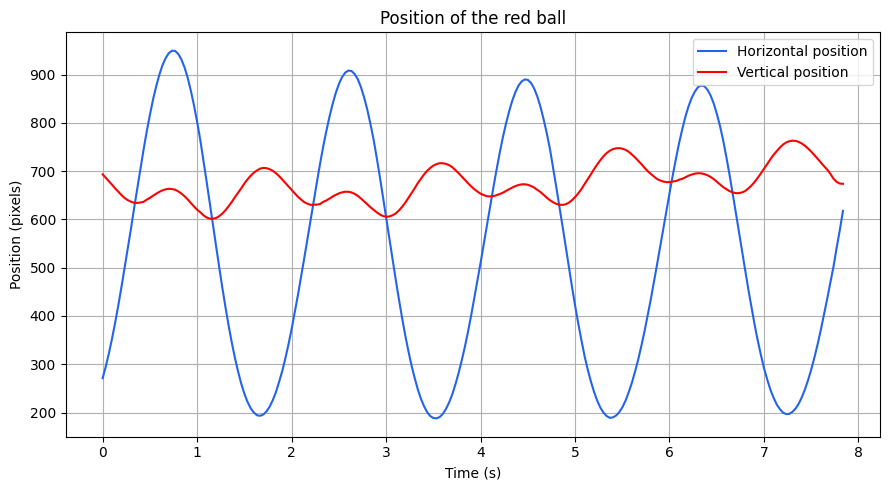

In [1]:
import cv2
import csv
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

VIDEO_FILE = "IMG_2750.MOV"
OUTPUT_VIDEO = "tracked_ball.mp4"
OUTPUT_CSV = "ball_position.csv"

# Ignore red objects smaller than this area
MINIMUM_AREA = 100

# Set this after calibration, if required.
# For pixel measurements, leave it equal to 1.
PIXELS_PER_METRE = 1.0


# ---------------------------------------------------------
# Open the video
# ---------------------------------------------------------

video = cv2.VideoCapture(VIDEO_FILE)

if not video.isOpened():
    raise FileNotFoundError(f"Could not open {VIDEO_FILE}")

fps = video.get(cv2.CAP_PROP_FPS)
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Frame rate: {fps:.2f} frames per second")
print(f"Frame size: {width} × {height} pixels")


# ---------------------------------------------------------
# Prepare the annotated output video
# ---------------------------------------------------------

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

output_video = cv2.VideoWriter(
    OUTPUT_VIDEO,
    fourcc,
    fps,
    (width, height)
)


# ---------------------------------------------------------
# Storage for measurements
# ---------------------------------------------------------

times = []
x_positions = []
y_positions = []

frame_number = 0


# ---------------------------------------------------------
# Process every frame
# ---------------------------------------------------------

while True:
    success, frame = video.read()

    if not success:
        break

    # Time corresponding to the current frame
    time = frame_number / fps

    # Lightly blur the image to reduce noise
    blurred = cv2.GaussianBlur(frame, (7, 7), 0)

    # Convert from BGR to HSV colour coordinates
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    # Red appears at both ends of OpenCV's hue scale,
    # so two red ranges are needed.
    lower_red_1 = np.array([0, 100, 80])
    upper_red_1 = np.array([10, 255, 255])

    lower_red_2 = np.array([170, 100, 80])
    upper_red_2 = np.array([179, 255, 255])

    mask_1 = cv2.inRange(hsv, lower_red_1, upper_red_1)
    mask_2 = cv2.inRange(hsv, lower_red_2, upper_red_2)

    red_mask = cv2.bitwise_or(mask_1, mask_2)

    # Remove isolated pixels and fill small gaps
    kernel = np.ones((5, 5), np.uint8)

    red_mask = cv2.morphologyEx(
        red_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    red_mask = cv2.morphologyEx(
        red_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Find all red regions
    contours, _ = cv2.findContours(
        red_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    ball_found = False

    if contours:
        # Assume the largest red region is the ball
        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)

        if area >= MINIMUM_AREA:
            moments = cv2.moments(largest_contour)

            if moments["m00"] != 0:
                centre_x = moments["m10"] / moments["m00"]
                centre_y_image = moments["m01"] / moments["m00"]

                # Convert the image y-coordinate so that upward is positive
                centre_y = height - centre_y_image

                x_position = centre_x / PIXELS_PER_METRE
                y_position = centre_y / PIXELS_PER_METRE

                times.append(time)
                x_positions.append(x_position)
                y_positions.append(y_position)

                ball_found = True

                # Draw the detected ball
                (circle_x, circle_y), radius = cv2.minEnclosingCircle(
                    largest_contour
                )

                centre = (int(circle_x), int(circle_y))

                cv2.circle(
                    frame,
                    centre,
                    int(radius),
                    (0, 255, 0),
                    3
                )

                cv2.circle(
                    frame,
                    centre,
                    4,
                    (255, 0, 0),
                    -1
                )

                label = (
                    f"t={time:.2f}s, "
                    f"x={x_position:.1f}, y={y_position:.1f}"
                )

                cv2.putText(
                    frame,
                    label,
                    (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 255, 0),
                    2
                )

    if not ball_found:
        cv2.putText(
            frame,
            "Ball not detected",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

    output_video.write(frame)
    frame_number += 1


# ---------------------------------------------------------
# Close the video files
# ---------------------------------------------------------

video.release()
output_video.release()

print(f"Processed {frame_number} frames")
print(f"Detected the ball in {len(times)} frames")


# ---------------------------------------------------------
# Save the position data
# ---------------------------------------------------------

with open(OUTPUT_CSV, "w", newline="") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["time_s", "x_position", "y_position"])

    for time, x, y in zip(times, x_positions, y_positions):
        writer.writerow([time, x, y])

print(f"Saved data to {OUTPUT_CSV}")
print(f"Saved annotated video to {OUTPUT_VIDEO}")


# ---------------------------------------------------------
# Plot position against time
# ---------------------------------------------------------

units = "m" if PIXELS_PER_METRE != 1.0 else "pixels"

plt.figure(figsize=(9, 5))

plt.plot(
    times,
    x_positions,
    label="Horizontal position",
    color="#2563eb"
)

plt.plot(
    times,
    y_positions,
    label="Vertical position",
    color="red"
)

plt.xlabel("Time (s)")
plt.ylabel(f"Position ({units})")
plt.title("Position of the red ball")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("ball_position.png", dpi=300)
plt.show()

In [ ]:
How do we convert this to 
(a) angular swing ?
(b) determine period of oscillator of this ?
